<a href="https://colab.research.google.com/github/elajeans/IMAG2023/blob/main/oppgave_5_elajean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

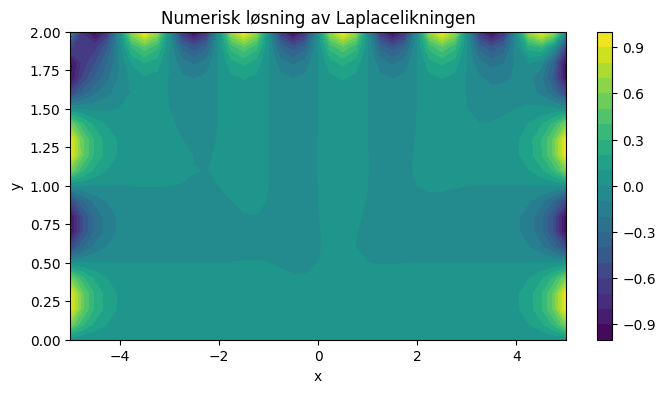

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Oppgave 5: Laplacelikning
# u_xx + u_yy = 0
# -5 < x < 5 , 0 < y < 2

# Antall gridpunkter
Nx = 41
Ny = 21

# Domene
x = np.linspace(-5, 5, Nx)
y = np.linspace(0, 2, Ny)

dx = x[1] - x[0]
dy = y[1] - y[0]

# Løsningsmatrise
u = np.zeros((Ny, Nx))

# Randbetingelser
# Venstre og høyre kant
for j in range(Ny):
    u[j, 0]  = np.sin(2 * np.pi * y[j])
    u[j, -1] = np.sin(2 * np.pi * y[j])

# Bunn
for i in range(Nx):
    u[0, i] = 0

# Topp
for i in range(Nx):
    u[-1, i] = np.sin(np.pi * x[i])


# Numerisk løsning (Jacobi-metoden)
iterations = 5000

for k in range(iterations):
    u_ny = u.copy()

    # Vektorisert oppdatering av indre punkter
    u_ny[1:-1, 1:-1] = 0.25 * (
        u[1:-1, 2:]  +   # høyre
        u[1:-1, :-2] +   # venstre
        u[2:,   1:-1] +  # opp
        u[:-2,  1:-1]    # ned
    )

    # Oppdater kun indre punkter (bevar randbetingelsene)
    u[1:-1, 1:-1] = u_ny[1:-1, 1:-1]


X, Y = np.meshgrid(x, y)

plt.figure(figsize=(8, 4))
plt.contourf(X, Y, u, 20)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Numerisk løsning av Laplacelikningen")
plt.show()